# Problem 01

In [1]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Mall_Customers.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "vjchoudhary7/customer-segmentation-tutorial-in-python",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

/tmp/ipykernel_5567/1847060566.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 3.89k/3.89k [00:00<00:00, 7.66MB/s]


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df['Gender'] = df['Gender'].map({
    'Male': 0,
    'Female': 1
})

In [4]:
# Why do you need to scale the features before applying K-Means?

# because it is a distance based algorithm

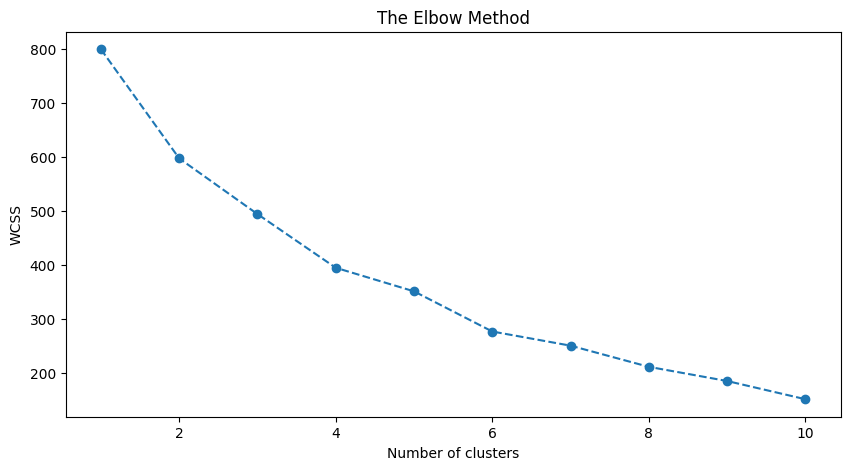

In [5]:
# Use the Elbow method (K=1 to 10). What is the optimal number of clusters?

X = df.drop(columns=['CustomerID'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


wcss = []
for i in range(1, 11):
  kmeans = KMeans(
      n_clusters = i,
      init = 'k-means++',
      random_state = 42,
      n_init='auto'
  )
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)


plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel("WCSS")
plt.show()


optimal k = 4/5

In [6]:
# Train K-Means with K=5. How many customers are in each cluster?

kmeans = KMeans(
    n_clusters = 5,
    init = 'k-means++',
    random_state = 42,
    n_init='auto'
)
kmeans.fit(X_scaled)
df['Cluster'] = kmeans.labels_
df['Cluster'].value_counts()

,count
Cluster,
0,51
3,49
2,42
4,38
1,20


In [7]:
# What are the cluster center coordinates for K=5?

centers = scaler.inverse_transform(kmeans.cluster_centers_)

print("Cluster Center Coordinates:")
for i, center in enumerate(centers):
    print(f"Cluster {i}: {center}")


Cluster Center Coordinates:
Cluster 0: [ 0.49019608 56.47058824 46.09803922 39.31372549]
Cluster 1: [ 0.   39.5  85.15 14.05]
Cluster 2: [ 0.         28.69047619 60.9047619  70.23809524]
Cluster 3: [ 1.         37.89795918 82.12244898 54.44897959]
Cluster 4: [ 1.         27.31578947 38.84210526 56.21052632]


cluster 2 has best spending score. So, should be targeted for luxury products

# Problem 02

In [8]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Iris.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/iris",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

/tmp/ipykernel_5567/1174990070.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'iris' dataset.


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
df2 = df.copy()

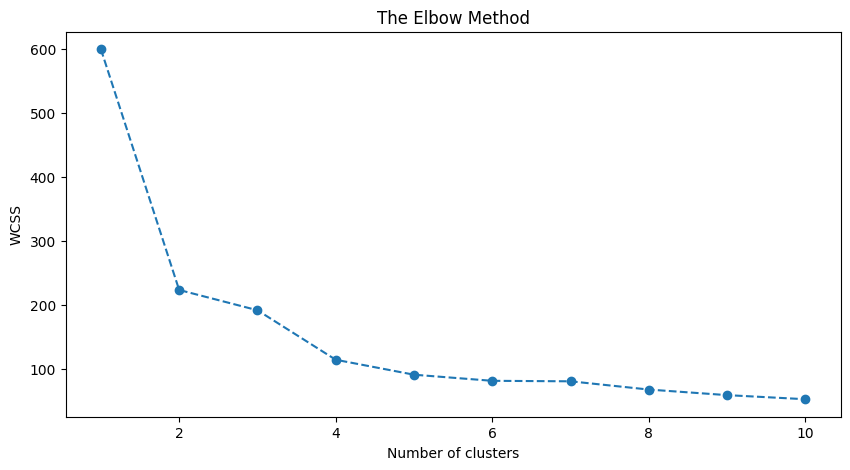

In [10]:
df['Species'] = df['Species'].map({
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
})
X = df.drop(columns=['Id', 'Species'])

X_scaled = StandardScaler().fit_transform(X)


# elbow method

wcss = []
for i in range(1, 11):
  kmeans = KMeans(
      n_clusters = i,
      init = 'k-means++',
      random_state = 42,
      n_init='auto'
  )
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)


plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel("WCSS")
plt.show()

In [11]:
# Silhouette Score

for k in range(2, 11):

    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print("K =", k, "Silhouette Score =", score)

K = 2 Silhouette Score = 0.580184463257396
K = 3 Silhouette Score = 0.4787241921049546
K = 4 Silhouette Score = 0.38724679456128813
K = 5 Silhouette Score = 0.3472646487546106
K = 6 Silhouette Score = 0.3362227657195823
K = 7 Silhouette Score = 0.26856231620835785
K = 8 Silhouette Score = 0.315682362622744
K = 9 Silhouette Score = 0.2991423157741052
K = 10 Silhouette Score = 0.3211028417222972


In [12]:
best_score = -1
best_k = 0

for k in range(2, 11):

    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    if score > best_score:
        best_score = score
        best_k = k

print("Best K:", best_k)
print("Best Silhouette Score:", best_score)

Best K: 2
Best Silhouette Score: 0.580184463257396


best k : 2


In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)


In [14]:
df['Cluster'] = labels
df['Cluster'].value_counts()

,count
Cluster,
0,96
1,32
2,22


In [15]:
df2

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [16]:
# Actual Species vs K-Means Cluster
comparison = pd.crosstab(
    df['Species'],
    kmeans.labels_,
    rownames=['Actual Species'],
    colnames=['K-Means Cluster']
)

print(comparison)

K-Means Cluster   0   1   2
Actual Species             
0                 0  32  18
1                46   0   4
2                50   0   0


# Problem 3: Credit Card Customer Segmentation

In [17]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "CC GENERAL.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "arjunbhasin2013/ccdata",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_5567/1809348009.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'ccdata' dataset.
First 5 records:   CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.00

In [18]:
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [20]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [21]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [22]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

In [23]:

df = df.drop(columns=['CUST_ID'])
X_scaled = StandardScaler().fit_transform(df)

Text(0, 0.5, 'WCSS')

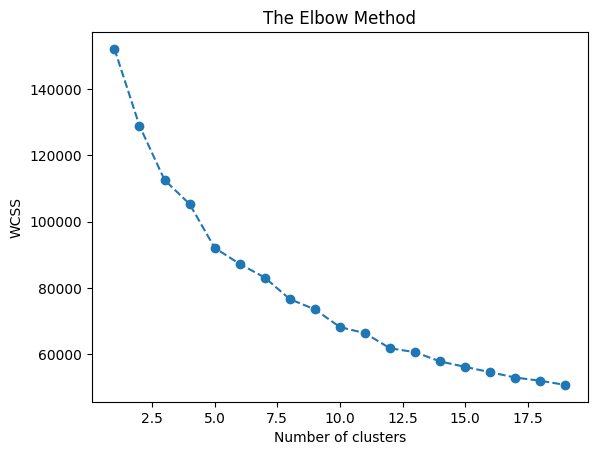

In [24]:

# elbow method

wcss = []
for i in range(1, 20):
  kmeans = KMeans(
      n_clusters = i,
      init = 'k-means++',
      random_state = 42,
      n_init='auto')
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)



plt.plot(range(1, 20), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel("WCSS")

In [25]:
# silhotte method

for k in range(2, 20):

    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print("K =", k, "Silhouette Score =", score)

K = 2 Silhouette Score = 0.27953987242960154
K = 3 Silhouette Score = 0.20671817817880617
K = 4 Silhouette Score = 0.1664601900140412
K = 5 Silhouette Score = 0.19256596919095406
K = 6 Silhouette Score = 0.19229183109910575
K = 7 Silhouette Score = 0.21527906424041757
K = 8 Silhouette Score = 0.20363733953443425
K = 9 Silhouette Score = 0.20375590708205218
K = 10 Silhouette Score = 0.21164744068517044
K = 11 Silhouette Score = 0.2130890537248857
K = 12 Silhouette Score = 0.21689834986402687
K = 13 Silhouette Score = 0.2183526764672107
K = 14 Silhouette Score = 0.21983731128526277
K = 15 Silhouette Score = 0.19488382075839408
K = 16 Silhouette Score = 0.20132965628949495
K = 17 Silhouette Score = 0.20639464967734644
K = 18 Silhouette Score = 0.2033305230682134
K = 19 Silhouette Score = 0.20765825755247916


In [26]:
# Train K-Means with K=4. What are the cluster sizes?

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = labels
df['Cluster'].value_counts()

,count
Cluster,
3,3368
2,3118
1,1487
0,977


In [27]:
# What are the average BALANCE, PURCHASES, CREDIT_LIMIT, and PAYMENTS for each cluster?

cluster_stats = df.groupby('Cluster').agg({
    'BALANCE': 'mean',
    'PURCHASES': 'mean',
    'CREDIT_LIMIT': 'mean',
    'PAYMENTS': 'mean'
})

print(cluster_stats)

             BALANCE    PURCHASES  CREDIT_LIMIT     PAYMENTS
Cluster                                                     
0        5010.394668   716.017789   8208.653578  4173.817878
1         108.430006   350.247868   3632.112008  1036.853064
2        1253.817942  2182.022178   5121.987288  2148.583305
3        1495.324927   283.482824   3216.349960   947.961448


Most profitable cluster = Cluster 1

# Problem 4: Anomaly Detection with K-Means

In [58]:

# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "creditcard.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_5567/415749099.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.
First 5 records:    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ...

In [49]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

```python
dataset-এর Class column ব্যবহার করবে:

    Class = 0 → Normal transaction
    Class = 1 → Fraud transaction

In [51]:
# Features and actual labels
X = df.drop(columns=['Class'])
y_true = df['Class']



# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [52]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [53]:
df['Class'].sum()

np.int64(492)

In [54]:
fraud_count = df['Class'].sum()

# Total transactions
total_count = len(df)

# Fraud percentage
fraud_percentage = (fraud_count / total_count) * 100

print("Fraud Transactions:", fraud_count)
print("Total Transactions:", total_count)
print("Fraud Percentage:", fraud_percentage, "%")

Fraud Transactions: 492
Total Transactions: 284807
Fraud Percentage: 0.1727485630620034 %


In [55]:
# Train K-Means with K=10. For each point, calculate distance to nearest cluster center.
kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)

distance = kmeans.transform(X_scaled).min(axis=1)
distance

array([3.03679672, 2.68049803, 5.46754855, ..., 4.40646886, 5.63897467,
       2.98720317])

```
transform()` কী করে? এটা প্রতিটা data point থেকে সবকটা cluster center পর্যন্ত distance হিসাব করে দেয়। তারপর আমরা প্রতিটা point-এর জন্য সবচেয়ে ছোট distance-টা রেখে দিই। মানে ওটা হলো ওই point-এর nearest বা সবচেয়ে কাছের cluster center পর্যন্ত দূরত্ব।

In [56]:
# Set a threshold at the 95th percentile of distances. How many frauds are detected?


threshold = np.percentile(distance, 95)

# Transactions above threshold are detected as anomalies/frauds
y_pred = (distance > threshold).astype(int)

# Number of detected frauds
detected_frauds = y_pred.sum()

print("95th Percentile Threshold:", threshold)
print("Number of Frauds Detected:", detected_frauds)

95th Percentile Threshold: 6.78701040844969
Number of Frauds Detected: 14241


In [57]:
# What is the precision and recall for fraud detection using this method?
from sklearn.metrics import precision_score, recall_score



y_true = df['Class']

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.02928165156941226
Recall: 0.8475609756097561


K-Means কিন্তু এই ধরো কিছু জিনিস assume করে। ক্লাস্টারগুলো গোল টাইপের হবে, প্রায় একই রকম সাইজের হবে, এইগুলো। তো, data-র যদি আসল ক্লাস্টার শেপ বা density আলাদা হয়, তাহলে distance মাপাটা misleading হতে পারে। আরেকটা সমস্যা হলো, এখানে K আগেই ঠিক করতে হয়। আর high-dimensional data-তে distance নিজেই কম informative হয়ে যায়। আর সবশেষে, K-Means anomaly-গুলোকে আলাদা ক্লাস্টার হিসেবে না দেখে, বরং কাছের ক্লাস্টারে টেনে নেয়। এতে অনেক সত্যিকারের anomaly miss হয়ে যায়। তাই high-recall fraud detection-এর জন্য এটা বেস্ট টুল না। অন্য পদ্ধতি বা domain-specific feature engineering এখানে বেশি ভালো কাজ করে।
